# NB-02 — EDA Capas Geoespaciales
## DataJam Bogotá 2026

**Objetivo:** Explorar todas las capas GeoJSON, JSON y el GDB de IDECA disponibles en Bronze.

**Secciones:**
1. Inventario del GDB (`gdb_mr_v06_26.gdb`)
2. Exploración de cada capa GeoJSON/JSON
3. Verificación de CRS, tipo de geometría, campos de join
4. Visualizaciones rápidas de capas clave
5. Tabla de decisiones

In [1]:
import os
import json
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
BRONZE = os.path.join(BASE, 'data', 'bronze')
print(f'Base: {BASE}')
print(f'Versión GeoPandas: {gpd.__version__}')

# Paleta de colores por localidad (para mapas)
import matplotlib.cm as cm
plt.rcParams['figure.dpi'] = 100

Base: /home/juliancelis/Documents/universidad/noveno_semestre/datajam
Versión GeoPandas: 1.1.4


## 1. Inventario del GDB (gdb_mr_v06_26.gdb)

In [2]:
import pyogrio

GDB_PATH = os.path.join(BRONZE, 'gdb_mr_v06_26.gdb')
print(f'GDB existe: {os.path.isdir(GDB_PATH)}')

try:
    capas_info_list = pyogrio.list_layers(GDB_PATH)
    print(f'Capas en GDB ({len(capas_info_list)} total):')
    print(capas_info_list)
    capas_resumen = []
    for nombre_capa in capas_info_list[:, 0]:
        try:
            info = pyogrio.read_info(GDB_PATH, layer=nombre_capa)
            gdf_s = gpd.read_file(GDB_PATH, layer=nombre_capa, rows=5, engine='pyogrio')
            capas_resumen.append({
                'capa': nombre_capa,
                'tipo_geom': str(gdf_s.geom_type.iloc[0]) if len(gdf_s) > 0 else 'N/A',
                'n_features': info.get('features', '?'),
                'crs_epsg': str(gdf_s.crs.to_epsg()) if gdf_s.crs else 'N/A',
                'columnas': ', '.join(gdf_s.columns[:5].tolist())
            })
            print(f'  OK {nombre_capa}: {info.get("features","?")} features')
        except Exception as e:
            capas_resumen.append({'capa': nombre_capa, 'error': str(e)})
            print(f'  ERR {nombre_capa}: {e}')
    gdb_df = pd.DataFrame(capas_resumen)
    print(gdb_df.to_string(index=False))
except Exception as e:
    print(f'Error leyendo GDB: {e}')
    try:
        gdf_test = gpd.read_file(GDB_PATH, rows=5, engine='pyogrio')
        print(f'Capa default cols: {list(gdf_test.columns)}')
    except Exception as e2:
        print(f'Error capa default: {e2}')


GDB existe: True
Capas en GDB (36 total):
[['Uso' None]
 ['ESoc' None]
 ['Predio' None]
 ['ESTADO' None]
 ['Manz' 'MultiPolygon']
 ['SCat' 'MultiPolygon']
 ['CDAg' 'MultiLineString']
 ['Muni' 'MultiPolygon']
 ['Loca' 'MultiPolygon']
 ['Corr' 'MultiPolygon']
 ['CPob' 'MultiPolygon']
 ['CPos' 'MultiPolygon']
 ['PGeo' 'Point']
 ['CAgu' 'MultiPolygon']
 ['PatioSITP' 'MultiPolygon Z']
 ['PSITP' 'Point']
 ['ETro' 'Point']
 ['Calz' 'MultiPolygon']
 ['Sepa' 'MultiPolygon']
 ['Cicl' 'MultiPolygon']
 ['Puen' 'MultiPolygon']
 ['RBic' 'MultiLineString']
 ['MVI' 'MultiLineString']
 ['AUrb' 'MultiPolygon']
 ['UPL' 'MultiPolygon']
 ['UPR' 'MultiPolygon']
 ['Suel' 'MultiPolygon']
 ['Cuenca' 'MultiPolygon']
 ['Microcuenca' 'MultiPolygon']
 ['SubCuenca' 'MultiPolygon']
 ['SubzonaHidrografica' 'MultiPolygon']
 ['NGeo' 'Point']
 ['fras_aux_PGeo' None]
 ['fras_blk_PGeo' None]
 ['fras_bnd_PGeo' None]
 ['fras_ras_PGeo' None]]
  ERR Uso: 'DataFrame' object has no attribute 'geom_type'
  ERR ESoc: 'DataFrame' 

  OK Corr: 3 features
  OK CPob: 11 features


  OK CPos: 81 features
  OK PGeo: 363 features
  OK CAgu: 677 features
  OK PatioSITP: 66 features
  OK PSITP: 7623 features
  OK ETro: 149 features
  OK Calz: 104558 features
  OK Sepa: 13738 features
  OK Cicl: 6311 features
  OK Puen: 1171 features


  OK RBic: 15985 features
  OK MVI: 139107 features


  OK AUrb: 7768 features
  OK UPL: 33 features
  OK UPR: 3 features
  OK Suel: 7 features
  OK Cuenca: 6 features
  OK Microcuenca: 39 features
  OK SubCuenca: 120 features
  OK SubzonaHidrografica: 7 features
  OK NGeo: 14071 features
  ERR fras_aux_PGeo: 'DataFrame' object has no attribute 'crs'


  ERR fras_blk_PGeo: 'DataFrame' object has no attribute 'crs'
  ERR fras_bnd_PGeo: 'DataFrame' object has no attribute 'crs'
  ERR fras_ras_PGeo: 'DataFrame' object has no attribute 'crs'


               capa                                           error       tipo_geom  n_features crs_epsg                                                                                       columnas
                Uso 'DataFrame' object has no attribute 'geom_type'             NaN         NaN      NaN                                                                                            NaN
               ESoc 'DataFrame' object has no attribute 'geom_type'             NaN         NaN      NaN                                                                                            NaN
             Predio 'DataFrame' object has no attribute 'geom_type'             NaN         NaN      NaN                                                                                            NaN
             ESTADO 'DataFrame' object has no attribute 'geom_type'             NaN         NaN      NaN                                                                                            NaN


## 2. Exploración de Capas GeoJSON — Inventario

In [3]:
GEOJSON_FILES = [
    ('DAILoc.geojson', 'Datos Ambientales por Localidad'),
    ('IRLoc.geojson', 'Indicador Residuos por Localidad'),
    ('IRUPZ.geojson', 'Indicador Residuos por UPZ'),
    ('cestas.geojson', 'Cestas de Basura'),
    ('contenerizacion.geojson', 'Contenedores'),
    ('cuadrantepolicia.geojson', 'Cuadrantes Policía'),
    ('ebom.geojson', 'Estaciones Bomberos'),
    ('macrorutas_de_barrido.geojson', 'Macrorutas Barrido'),
    ('puntos_criticos_arrojo_clandestino_residuos.geojson', 'Puntos Críticos Arrojo'),
]
# Nota: IRSCAT.geojson, estacionpolicia.geojson, macrorutasrecoleccion.geojson,
# manzanaestratificacion.json y predioruralestrato.json fueron eliminados del proyecto
# por no corresponder a ninguna de las 13 fuentes de datos declaradas (ver conversación
# donde se decidió limpiar Bronze/ a solo lo declarado).

JSON_FILES = []

inventario_geo = []

print('=== INVENTARIO DE CAPAS GEOESPACIALES ===\n')
for fname, desc in GEOJSON_FILES:
    fpath = os.path.join(BRONZE, fname)
    size_mb = os.path.getsize(fpath) / 1024**2
    try:
        # Para archivos grandes, solo leer metadatos
        if size_mb > 20:
            gdf = gpd.read_file(fpath, rows=100, engine='pyogrio')
            n_features = '> muestra (archivo grande)'
        else:
            gdf = gpd.read_file(fpath, engine='pyogrio')
            n_features = len(gdf)
        
        inventario_geo.append({
            'archivo': fname,
            'descripcion': desc,
            'size_mb': round(size_mb, 1),
            'tipo_geom': str(gdf.geom_type.value_counts().idxmax()) if len(gdf) > 0 else 'N/A',
            'n_features': n_features,
            'crs': str(gdf.crs.to_epsg()) if gdf.crs else 'N/A',
            'n_columnas': gdf.shape[1],
            'columnas_muestra': ', '.join(gdf.columns[:5].tolist()),
            'pct_nulos_geom': round(gdf.geometry.isna().mean() * 100, 1)
        })
        print(f'✅ {fname} ({size_mb:.1f} MB)')
        print(f'   Tipo: {gdf.geom_type.value_counts().idxmax()} | CRS: EPSG:{gdf.crs.to_epsg() if gdf.crs else "N/A"} | Cols: {gdf.shape[1]}')
        print(f'   Columnas: {list(gdf.columns[:6])}')
        print()
    except Exception as e:
        inventario_geo.append({'archivo': fname, 'descripcion': desc, 'error': str(e)})
        print(f'❌ {fname}: {e}\n')

=== INVENTARIO DE CAPAS GEOESPACIALES ===

✅ DAILoc.geojson (2.2 MB)
   Tipo: Polygon | CRS: EPSG:4686 | Cols: 127
   Columnas: ['CMIULOCAL', 'CMNOMLOCAL', 'CMMES', 'CMH18CONT', 'CMH19CONT', 'CMH20CONT']

✅ IRLoc.geojson (2.2 MB)
   Tipo: Polygon | CRS: EPSG:4686 | Cols: 105
   Columnas: ['CMIULOCAL', 'CMNOMLOCAL', 'CMMES', 'CMR18CONT', 'CMR19CONT', 'CMR20CONT']



✅ IRUPZ.geojson (3.4 MB)
   Tipo: Polygon | CRS: EPSG:4686 | Cols: 105
   Columnas: ['CMIUUPLA', 'CMNOMUPLA', 'CMMES', 'CMR18CONT', 'CMR19CONT', 'CMR20CONT']



✅ cestas.geojson (50.6 MB)
   Tipo: Point | CRS: EPSG:3857 | Cols: 18
   Columnas: ['IDSEQ', 'CODINTERNO', 'IDLOCALID', 'DIRECCION', 'CAPACIDAD', 'APROVECHAB']

✅ contenerizacion.geojson (3.6 MB)
   Tipo: Point | CRS: EPSG:3857 | Cols: 10
   Columnas: ['CODINTERNO', 'DIRECCION', 'CAPACIDAD', 'APROVECHAB', 'FECVIGDES', 'SERIAL']



✅ cuadrantepolicia.geojson (1.1 MB)
   Tipo: Polygon | CRS: EPSG:4686 | Cols: 18
   Columnas: ['PCUNCUADRA', 'PCUCOSEC', 'PCUNOMEST', 'PCUNOMCAI', 'PCUCODIGO', 'PCUTELEFON']

✅ ebom.geojson (0.0 MB)
   Tipo: Point | CRS: EPSG:4686 | Cols: 6
   Columnas: ['OBJECTID', 'EBONOMBRE', 'EBODIRECCI', 'EBOTELEFON', 'EBOJEFE', 'geometry']



✅ macrorutas_de_barrido.geojson (33.8 MB)
   Tipo: MultiPolygon | CRS: EPSG:4326 | Cols: 10
   Columnas: ['GmlID', 'OBJECTID', 'Fecha_inicio_vigencia', 'Nombre_Localidad', 'Hora_fin_Recolección', 'Hora_Inicio_Recolección']

✅ puntos_criticos_arrojo_clandestino_residuos.geojson (0.1 MB)
   Tipo: Point | CRS: EPSG:4326 | Cols: 7
   Columnas: ['GmlID', 'OBJECTID', 'Nombre_Localidad', 'Frecuencia', 'Dirección', 'Observación']



In [4]:
print('=== ARCHIVOS JSON GRANDES (muestra) ===\n')
for fname, desc in JSON_FILES:
    fpath = os.path.join(BRONZE, fname)
    size_mb = os.path.getsize(fpath) / 1024**2
    print(f'📦 {fname} ({size_mb:.1f} MB) — {desc}')
    try:
        # Leer solo primeros bytes para identificar estructura
        with open(fpath, 'r', encoding='utf-8', errors='replace') as f:
            inicio = f.read(2000)
        print(f'   Inicio del archivo: {inicio[:500]}')
        
        # Intentar leer como GeoJSON con geopandas (muestra)
        try:
            gdf = gpd.read_file(fpath, rows=50, engine='pyogrio')
            print(f'   ✅ Es GeoJSON válido | Tipo geom: {gdf.geom_type.value_counts().idxmax()}')
            print(f'   Columnas: {list(gdf.columns)}')
            inventario_geo.append({
                'archivo': fname, 'descripcion': desc,
                'size_mb': round(size_mb, 1),
                'tipo_geom': str(gdf.geom_type.value_counts().idxmax()),
                'crs': str(gdf.crs.to_epsg()) if gdf.crs else 'N/A',
                'columnas_muestra': ', '.join(gdf.columns[:5].tolist())
            })
        except Exception:
            # Intentar como JSON plano
            with open(fpath, 'r', encoding='utf-8', errors='replace') as f:
                data = json.loads(f.read(50000))
            print(f'   📋 JSON plano — keys: {list(data.keys()) if isinstance(data, dict) else type(data)}')
    except Exception as e:
        print(f'   ❌ Error: {e}')
    print()

=== ARCHIVOS JSON GRANDES (muestra) ===



## 3. Verificación de Campos de Join

In [5]:
# Capas clave para el análisis: UPZ y Localidades
CAMPOS_JOIN = ['upz', 'localidad', 'cod', 'codigo', 'id', 'nombre']

capas_join = [
    ('IRUPZ.geojson', 'UPZ'),
    ('IRLoc.geojson', 'Localidades'),
    ('DAILoc.geojson', 'Dat. Ambientales Loc'),
    ('puntos_criticos_arrojo_clandestino_residuos.geojson', 'Puntos Críticos'),
    ('contenerizacion.geojson', 'Contenerización'),
    ('cuadrantepolicia.geojson', 'Cuadrantes Policía'),
]

print('=== CAMPOS DE JOIN IDENTIFICADOS ===\n')
for fname, desc in capas_join:
    fpath = os.path.join(BRONZE, fname)
    try:
        rows = 5 if os.path.getsize(fpath)/1024**2 < 20 else 5
        gdf = gpd.read_file(fpath, rows=rows, engine='pyogrio')
        cols_lower = {c.lower(): c for c in gdf.columns}
        encontrados = [(c, cols_lower[c]) for c in CAMPOS_JOIN if c in cols_lower]
        print(f'📋 {desc} ({fname})')
        print(f'   Columnas: {list(gdf.columns)}')
        print(f'   Posibles join keys: {[v for _, v in encontrados]}')
        if len(gdf) > 0:
            print(f'   Muestra (primera fila): {gdf.iloc[0].drop("geometry").to_dict()}')
        print()
    except Exception as e:
        print(f'❌ {desc}: {e}')

=== CAMPOS DE JOIN IDENTIFICADOS ===

📋 UPZ (IRUPZ.geojson)
   Columnas: ['CMIUUPLA', 'CMNOMUPLA', 'CMMES', 'CMR18CONT', 'CMR19CONT', 'CMR20CONT', 'CMRVAR', 'CMRTOTAL', 'CMN18CONT', 'CMN19CONT', 'CMN20CONT', 'CMNVAR', 'CMNTOTAL', 'CMAOP18CON', 'CMAOP19CON', 'CMAOP20CON', 'CMAOPVAR', 'CMAOPTOTAL', 'CMMM18CONT', 'CMMM19CONT', 'CMMM20CONT', 'CMMMVAR', 'CMMMTOTAL', 'CMR21CONT', 'CMN21CONT', 'CMAOP21CON', 'CMMM21CONT', 'CMR22CONT', 'CMN22CONT', 'CMAOP22CON', 'CMMM22CONT', 'CMR23CONT', 'CMN23CONT', 'CMAOP23CON', 'CMMM23CONT', 'CMM18CONT', 'CMM19CONT', 'CMM20CONT', 'CMM21CONT', 'CMM22CONT', 'CMM23CONT', 'CMMVAR', 'CMMTOTAL', 'CMR24CONT', 'CMN24CONT', 'CMAOP24CON', 'CMMM24CONT', 'CMM24CONT', 'CMR25CONT', 'CMN25CONT', 'CMAOP25CON', 'CMMM25CONT', 'CMM25CONT', 'CMD18CONT', 'CMD19CONT', 'CMD20CONT', 'CMD21CONT', 'CMD22CONT', 'CMD23CONT', 'CMD24CONT', 'CMD25CONT', 'CMDVAR', 'CMDTOTAL', 'CMPIA18CON', 'CMPIA19CON', 'CMPIA20CON', 'CMPIA21CON', 'CMPIA22CON', 'CMPIA23CON', 'CMPIA24CON', 'CMPIA25CON', 'C

## 4. Visualizaciones de Capas Clave

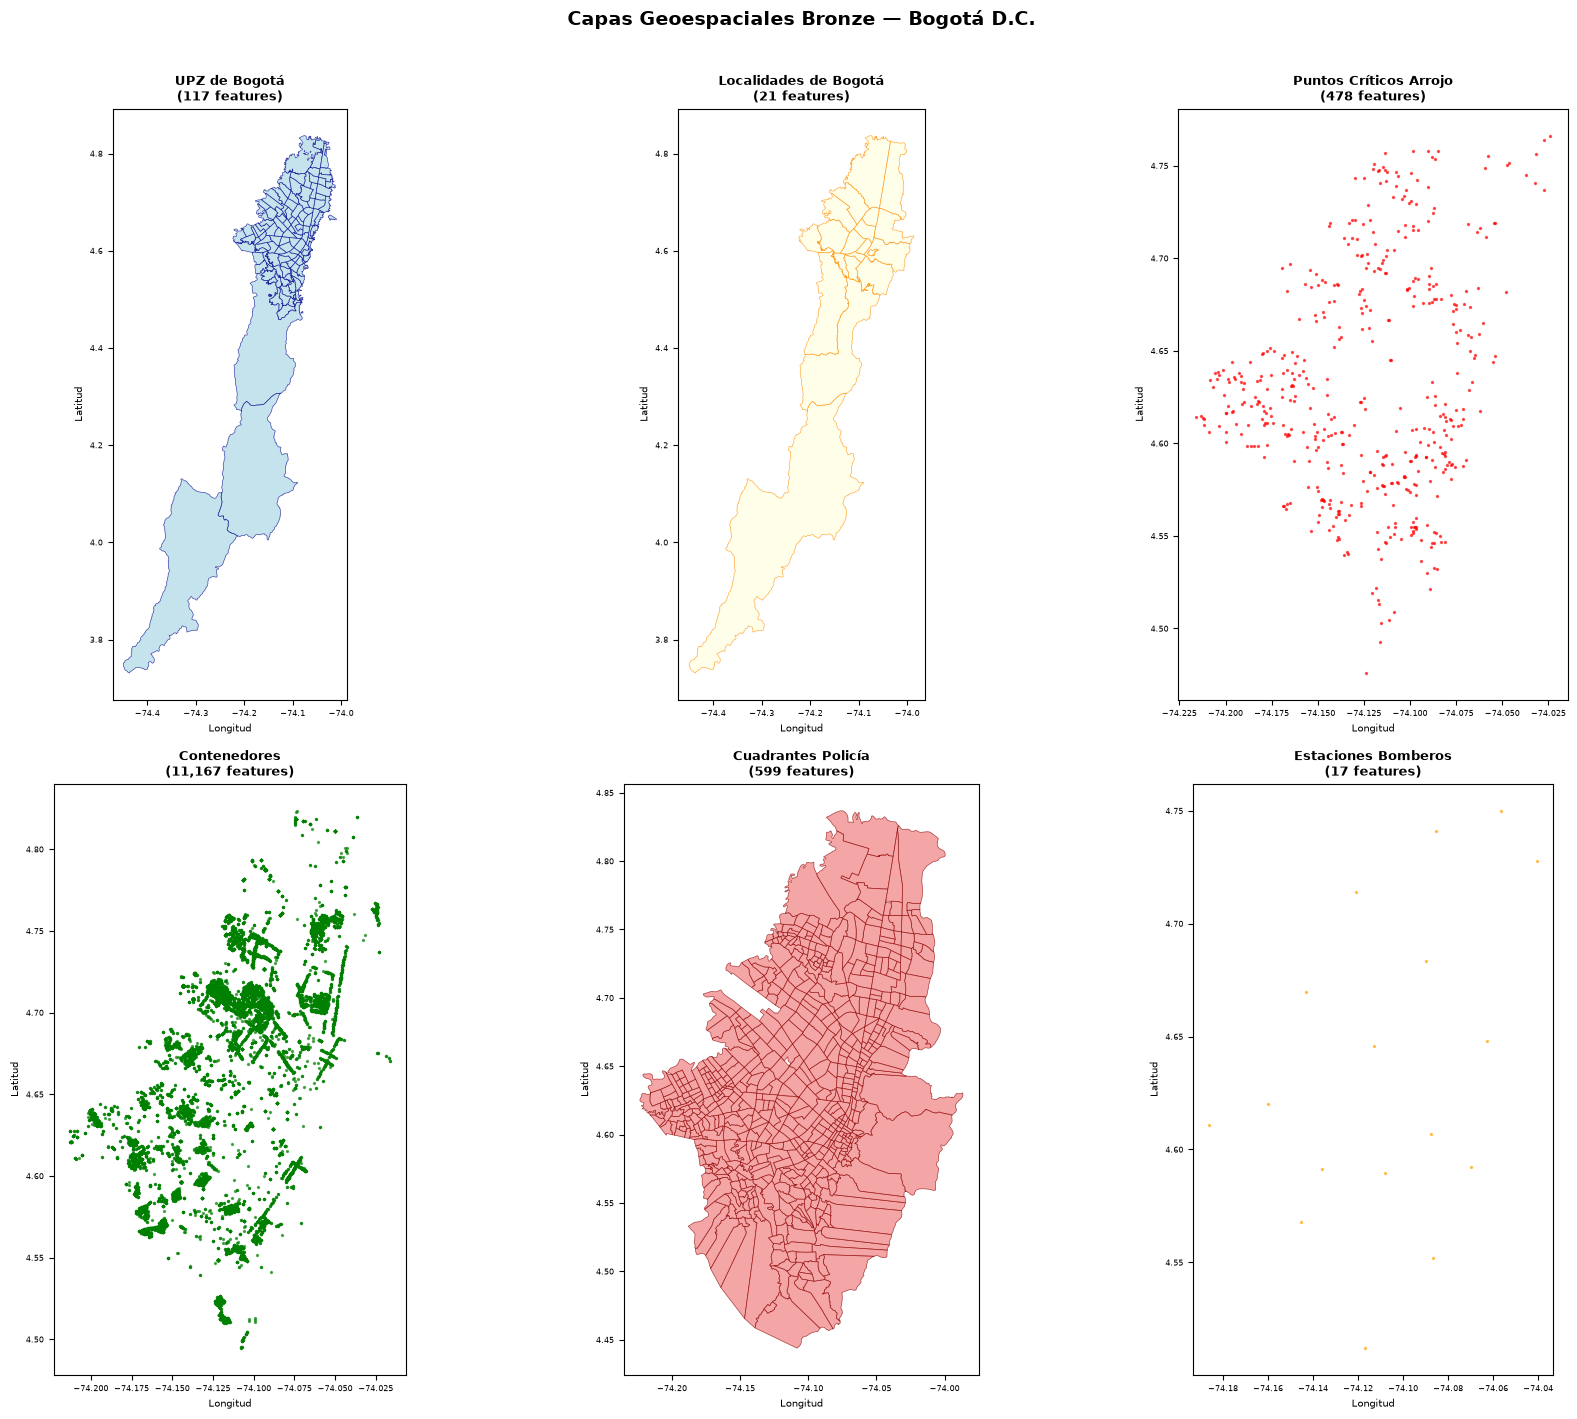

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 14))
axes = axes.flatten()

capas_visualizar = [
    ('IRUPZ.geojson', 'UPZ de Bogotá', 'lightblue', 'darkblue'),
    ('IRLoc.geojson', 'Localidades de Bogotá', 'lightyellow', 'darkorange'),
    ('puntos_criticos_arrojo_clandestino_residuos.geojson', 'Puntos Críticos Arrojo', None, 'red'),
    ('contenerizacion.geojson', 'Contenedores', None, 'green'),
    ('cuadrantepolicia.geojson', 'Cuadrantes Policía', 'lightcoral', 'darkred'),
    ('ebom.geojson', 'Estaciones Bomberos', None, 'orange'),
]

for i, (fname, titulo, color_fill, color_edge) in enumerate(capas_visualizar):
    ax = axes[i]
    fpath = os.path.join(BRONZE, fname)
    try:
        if os.path.getsize(fpath)/1024**2 > 20:
            gdf = gpd.read_file(fpath, rows=500, engine='pyogrio')
            titulo += ' (muestra 500)'
        else:
            gdf = gpd.read_file(fpath, engine='pyogrio')
        
        # Re-proyectar a WGS84 si es necesario
        if gdf.crs and gdf.crs.to_epsg() != 4326:
            gdf = gdf.to_crs(epsg=4326)
        
        if gdf.geom_type.iloc[0] in ['Point', 'MultiPoint'] if len(gdf) > 0 else False:
            gdf.plot(ax=ax, color=color_edge, markersize=2, alpha=0.6)
        else:
            gdf.plot(ax=ax, facecolor=color_fill or 'lightgray',
                     edgecolor=color_edge, linewidth=0.5, alpha=0.7)
        
        ax.set_title(f'{titulo}\n({len(gdf):,} features)', fontsize=9, fontweight='bold')
        ax.set_xlabel('Longitud', fontsize=7)
        ax.set_ylabel('Latitud', fontsize=7)
        ax.tick_params(labelsize=6)
    except Exception as e:
        ax.text(0.5, 0.5, f'Error:\n{e}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(titulo, fontsize=9)

plt.suptitle('Capas Geoespaciales Bronze — Bogotá D.C.', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/02_capas_geo_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análisis de Nulos y Calidad por Capa

In [7]:
print('=== ANÁLISIS DE CALIDAD POR CAPA ===\n')
for fname, desc in GEOJSON_FILES:
    fpath = os.path.join(BRONZE, fname)
    try:
        size_mb = os.path.getsize(fpath) / 1024**2
        nrows = 1000 if size_mb > 20 else None
        gdf = gpd.read_file(fpath, rows=nrows, engine='pyogrio')
        
        pct_geom_null = gdf.geometry.isna().mean() * 100
        pct_geom_invalid = (~gdf.geometry.is_valid).mean() * 100 if len(gdf) > 0 else 0
        
        # Nulos por columna atributo
        attr_cols = [c for c in gdf.columns if c != 'geometry']
        pct_nulos_attrs = gdf[attr_cols].isnull().mean().mean() * 100 if attr_cols else 0
        
        status = '✅' if pct_geom_null < 5 and pct_geom_invalid < 5 else '⚠️'
        print(f'{status} {desc} ({fname})')
        print(f'   Geometrías nulas: {pct_geom_null:.1f}% | Inválidas: {pct_geom_invalid:.1f}%')
        print(f'   % nulos en atributos: {pct_nulos_attrs:.1f}%')
        if nrows:
            print(f'   (Calculado sobre muestra de {nrows} filas de {size_mb:.1f} MB)')
        print()
    except Exception as e:
        print(f'❌ {desc}: {e}\n')

=== ANÁLISIS DE CALIDAD POR CAPA ===

✅ Datos Ambientales por Localidad (DAILoc.geojson)
   Geometrías nulas: 4.8% | Inválidas: 4.8%
   % nulos en atributos: 0.0%

✅ Indicador Residuos por Localidad (IRLoc.geojson)
   Geometrías nulas: 4.8% | Inválidas: 4.8%
   % nulos en atributos: 0.0%

✅ Indicador Residuos por UPZ (IRUPZ.geojson)
   Geometrías nulas: 0.9% | Inválidas: 0.9%
   % nulos en atributos: 0.0%



✅ Cestas de Basura (cestas.geojson)
   Geometrías nulas: 0.0% | Inválidas: 0.0%
   % nulos en atributos: 5.9%
   (Calculado sobre muestra de 1000 filas de 50.6 MB)

✅ Contenedores (contenerizacion.geojson)
   Geometrías nulas: 0.0% | Inválidas: 0.0%
   % nulos en atributos: 17.1%

✅ Cuadrantes Policía (cuadrantepolicia.geojson)
   Geometrías nulas: 0.0% | Inválidas: 0.0%
   % nulos en atributos: 0.0%

✅ Estaciones Bomberos (ebom.geojson)
   Geometrías nulas: 0.0% | Inválidas: 0.0%
   % nulos en atributos: 0.0%



⚠️ Macrorutas Barrido (macrorutas_de_barrido.geojson)
   Geometrías nulas: 0.0% | Inválidas: 89.9%
   % nulos en atributos: 0.0%
   (Calculado sobre muestra de 1000 filas de 33.8 MB)

✅ Puntos Críticos Arrojo (puntos_criticos_arrojo_clandestino_residuos.geojson)
   Geometrías nulas: 0.0% | Inválidas: 0.0%
   % nulos en atributos: 0.0%



## 6. Tabla de Decisiones

In [8]:
decisiones_geo = [
    ('IRUPZ.geojson', 'UPZ Bogotá', '✅ USAR — Unidad principal de análisis. Join clave.'),
    ('IRLoc.geojson', 'Localidades', '✅ USAR — Geometría de localidades para mapas base.'),
    ('DAILoc.geojson', 'Datos Ambientales Loc', '⚠️ EVALUAR — Revisar atributos, puede complementar IRLoc.'),
    ('cestas.geojson', 'Cestas', '✅ USAR — Variable X₂ clave. Densidad por UPZ.'),
    ('contenerizacion.geojson', 'Contenedores', '✅ USAR — Complemento de cestas. Infraestructura de aseo.'),
    ('cuadrantepolicia.geojson', 'Cuadrantes Policía', '⚠️ EVALUAR — Proxy espacial si incidentes no tienen lat/lon.'),
    ('ebom.geojson', 'Estaciones Bomberos', '✅ USAR — Join con incidentes UAECOB (campo ESTACIÓN).'),
    ('macrorutas_de_barrido.geojson', 'Rutas Barrido', '✅ USAR — Variable X₃: % cobertura de barrido por UPZ.'),
    ('puntos_criticos_arrojo_clandestino_residuos.geojson', 'Puntos Críticos', '✅ USAR — Variable Y₂ principal de la hipótesis.'),
    ('gdb_mr_v06_26.gdb', 'GDB IDECA', '⚠️ EVALUAR — Inventariar capas. Tomar solo las relevantes.'),
]
# IRSCAT.geojson, estacionpolicia.geojson, macrorutasrecoleccion.geojson,
# manzanaestratificacion.json y predioruralestrato.json ya no están en Bronze/
# (eliminados por no pertenecer a las 13 fuentes declaradas del proyecto).

dec_geo_df = pd.DataFrame(decisiones_geo, columns=['archivo', 'descripcion', 'decision'])
print('=== TABLA DE DECISIONES — CAPAS GEOESPACIALES ===')
print(dec_geo_df.to_string(index=False))

os.makedirs('../Silver', exist_ok=True)
dec_geo_df.to_csv('../Silver/decisiones_geo.csv', index=False)
print('\n✅ NB-02 completado. Guardado en Silver/decisiones_geo.csv')

=== TABLA DE DECISIONES — CAPAS GEOESPACIALES ===
                                            archivo           descripcion                                                     decision
                                      IRUPZ.geojson            UPZ Bogotá           ✅ USAR — Unidad principal de análisis. Join clave.
                                      IRLoc.geojson           Localidades           ✅ USAR — Geometría de localidades para mapas base.
                                     DAILoc.geojson Datos Ambientales Loc    ⚠️ EVALUAR — Revisar atributos, puede complementar IRLoc.
                                     cestas.geojson                Cestas                ✅ USAR — Variable X₂ clave. Densidad por UPZ.
                            contenerizacion.geojson          Contenedores     ✅ USAR — Complemento de cestas. Infraestructura de aseo.
                           cuadrantepolicia.geojson    Cuadrantes Policía ⚠️ EVALUAR — Proxy espacial si incidentes no tienen lat/lon.
     